# Submission Klasifikasi Gambar — Intel Image Classification
Dicoding — Belajar Pengembangan Machine Learning

Dataset: **Intel Image Classification** (Kaggle) — 6 kelas (buildings, forest, glacier, mountain, sea, street), total ±25.000 gambar, resolusi asli tidak seragam (dijaga tidak di-resize permanen).

Target: akurasi training dan validasi ≥ 95%, model diekspor ke SavedModel, TF-Lite, dan TFJS.

## 1. Setup & Download Dataset (Kaggle API)

Upload file `kaggle.json` (API token dari akun Kaggle: Account > Create New API Token) sebelum menjalankan sel ini.

In [1]:
# Install dependency utama
!pip install -q kaggle tensorflowjs pyyaml

import os

# Upload kaggle.json jika belum ada
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Silakan upload file kaggle.json Anda:")
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    for fn in uploaded:
        os.rename(fn, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
google-cloud-bigquery 3.42.2 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have te

Saving kaggle.json to kaggle.json


In [2]:
# Download dataset Intel Image Classification dari Kaggle
!kaggle datasets download -d puneet6060/intel-image-classification -p /content/data --unzip

DATA_ROOT = '/content/data'
!ls {DATA_ROOT}


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:04<00:00, 85.1MB/s]

seg_pred  seg_test  seg_train


In [3]:
# Dataset Intel Image Classification sudah punya folder seg_train dan seg_test bawaan.
# Kita akan gabungkan semua gambar per kelas ke satu folder master, lalu kita split ulang
# sendiri menjadi train/val/test 80/10/10 sesuai kriteria submission.

import shutil, glob

RAW_TRAIN = os.path.join(DATA_ROOT, 'seg_train', 'seg_train')
RAW_TEST  = os.path.join(DATA_ROOT, 'seg_test', 'seg_test')

MASTER_DIR = '/content/master_dataset'
if os.path.exists(MASTER_DIR):
    shutil.rmtree(MASTER_DIR)
os.makedirs(MASTER_DIR, exist_ok=True)

class_names = sorted(os.listdir(RAW_TRAIN))
print("Kelas ditemukan:", class_names)

for cls in class_names:
    dst = os.path.join(MASTER_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    for src_root in [RAW_TRAIN, RAW_TEST]:
        src = os.path.join(src_root, cls)
        if not os.path.isdir(src):
            continue
        for fname in os.listdir(src):
            src_path = os.path.join(src, fname)
            dst_path = os.path.join(dst, f"{os.path.basename(src_root)}_{fname}")
            shutil.copy2(src_path, dst_path)

total = sum(len(os.listdir(os.path.join(MASTER_DIR, c))) for c in class_names)
print("Total gambar terkumpul:", total)


Kelas ditemukan: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total gambar terkumpul: 17034


## 2. Eksplorasi Data & Resolusi Gambar

Dataset asli tidak di-resize permanen. Kita hanya mengecek jumlah gambar per kelas dan variasi resolusinya menggunakan PIL.

In [4]:
from PIL import Image
import pandas as pd

def check_image_resolutions(root_dir, sample_per_class=30):
    records = []
    for cls in sorted(os.listdir(root_dir)):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        files_list = os.listdir(cls_dir)[:sample_per_class]
        for fname in files_list:
            try:
                with Image.open(os.path.join(cls_dir, fname)) as img:
                    records.append({'class': cls, 'width': img.width, 'height': img.height, 'mode': img.mode})
            except Exception as e:
                print("Gagal baca:", fname, e)
    return pd.DataFrame(records)

res_df = check_image_resolutions(MASTER_DIR)
print(res_df.groupby('class').size())
print("\nStatistik resolusi (sampel):")
print(res_df[['width', 'height']].describe())


class
buildings    30
forest       30
glacier      30
mountain     30
sea          30
street       30
dtype: int64

Statistik resolusi (sampel):
       width      height
count  180.0  180.000000
mean   150.0  149.800000
std      0.0    1.705725
min    150.0  134.000000
25%    150.0  150.000000
50%    150.0  150.000000
75%    150.0  150.000000
max    150.0  150.000000


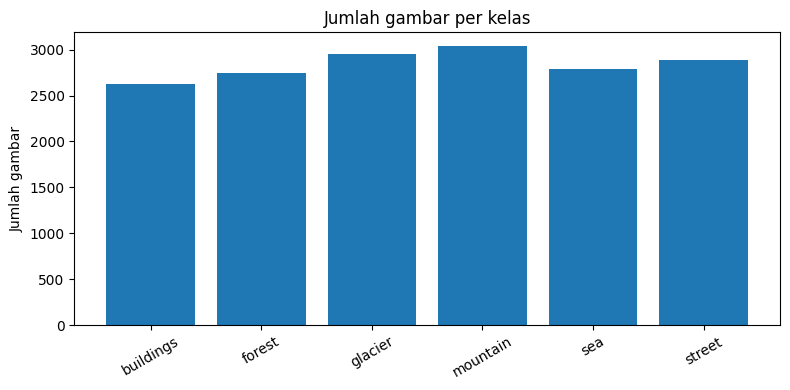

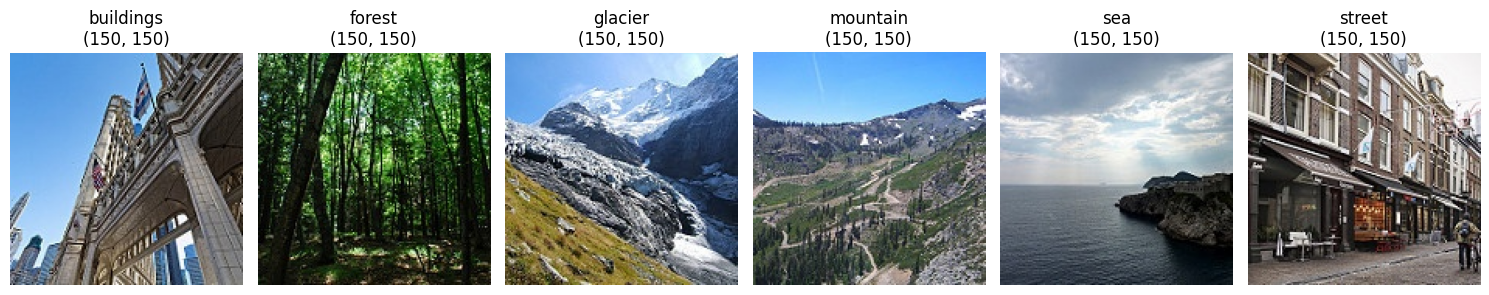

In [5]:
import matplotlib.pyplot as plt

# Distribusi jumlah gambar per kelas (dari seluruh dataset, bukan sampel)
counts = {c: len(os.listdir(os.path.join(MASTER_DIR, c))) for c in class_names}

plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values())
plt.title('Jumlah gambar per kelas')
plt.ylabel('Jumlah gambar')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Contoh gambar tiap kelas (menampilkan resolusi asli, tidak di-resize permanen di disk)
plt.figure(figsize=(15, 6))
for i, cls in enumerate(class_names):
    cls_dir = os.path.join(MASTER_DIR, cls)
    sample_file = os.listdir(cls_dir)[0]
    img = Image.open(os.path.join(cls_dir, sample_file))
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    plt.title(f"{cls}\n{img.size}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Data Splitting & Preprocessing

Split 80% train / 10% validation / 10% test. File di-*copy* ke folder split baru (dataset master tetap utuh, tidak ada resize permanen). Augmentasi lewat `ImageDataGenerator` hanya diterapkan pada training set; validation dan test hanya `rescale=1./255`.

In [8]:
import os

!pip install -q split-folders
import splitfolders

SPLIT_DIR = '/content/split_dataset'
splitfolders.ratio(MASTER_DIR, output=SPLIT_DIR, seed=42, ratio=(0.8, 0.1, 0.1))

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    total = sum(len(os.listdir(os.path.join(d, c))) for c in class_names)
    print(d, '->', total, 'gambar')

Copying files: 17034 files [00:02, 6697.20 files/s]

/content/split_dataset/train -> 13625 gambar
/content/split_dataset/val -> 1700 gambar
/content/split_dataset/test -> 1709 gambar


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Augmentasi HANYA untuk training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & test: hanya rescaling, tanpa augmentasi
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("Label mapping:", train_generator.class_indices)
num_classes = len(train_generator.class_indices)


Found 13625 images belonging to 6 classes.
Found 1700 images belonging to 6 classes.
Found 1709 images belonging to 6 classes.
Label mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## 4. Membangun Model (Sequential)

CNN sederhana dengan blok `Conv2D` + `MaxPooling2D` berulang, diakhiri `Flatten`, `Dense`, dan `Dropout` untuk mengurangi overfitting.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457,094 (13.19 MB)

 Trainable params: 3,456,390 (13.19 MB)

 Non-trainable params: 704 (2.75 KB)

## 5. Custom Callback

Training otomatis berhenti ketika `accuracy >= 0.96` dan `val_accuracy >= 0.96` tercapai bersamaan, agar tidak overfitting akibat epoch berlebih.

In [11]:
class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, acc_threshold=0.96, val_acc_threshold=0.96):
        super().__init__()
        self.acc_threshold = acc_threshold
        self.val_acc_threshold = val_acc_threshold

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        if acc >= self.acc_threshold and val_acc >= self.val_acc_threshold:
            print(f"\nEpoch {epoch+1}: accuracy={acc:.4f} dan val_accuracy={val_acc:.4f} "
                  f"sudah melewati target {self.acc_threshold}. Training dihentikan.")
            self.model.stop_training = True

threshold_callback = AccuracyThresholdCallback(acc_threshold=0.96, val_acc_threshold=0.96)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)


## 6. Training Model

In [12]:
EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[threshold_callback, early_stop, reduce_lr],
    verbose=1
)


Epoch 1/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 104s 223ms/step - accuracy: 0.6335 - loss: 1.0715 - val_accuracy: 0.5318 - val_loss: 1.4222 - learning_rate: 3.0000e-04
Epoch 2/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 86s 202ms/step - accuracy: 0.7381 - loss: 0.7243 - val_accuracy: 0.7876 - val_loss: 0.5756 - learning_rate: 3.0000e-04
Epoch 3/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 85s 198ms/step - accuracy: 0.7698 - loss: 0.6507 - val_accuracy: 0.7559 - val_loss: 0.7447 - learning_rate: 3.0000e-04
Epoch 4/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 86s 203ms/step - accuracy: 0.7871 - loss: 0.5891 - val_accuracy: 0.7088 - val_loss: 0.8770 - learning_rate: 3.0000e-04
Epoch 5/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 87s 203ms/step - accuracy: 0.8221 - loss: 0.4886 - val_accuracy: 0.8500 - val_loss: 0.4293 - learning_rate: 1.5000e-04
Epoch 6/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 85s 199ms/step - accuracy: 0.8410 - loss: 0.4451 - val_accuracy: 0.8424 - val_loss: 0.4597 - learning_rate: 1.5000e-04
Epoch 7/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 85s 1

## 7. Plot Akurasi & Loss

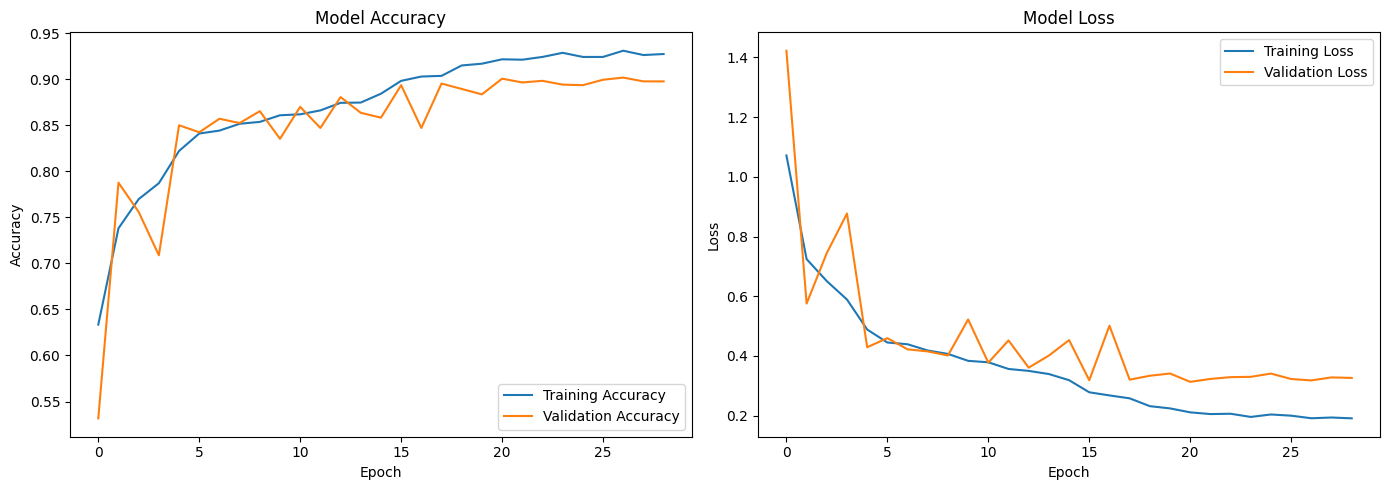

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


## 8. Evaluasi Model pada Test Set

In [14]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8748 - loss: 0.3629
Test Loss: 0.3629
Test Accuracy: 0.8748


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step
              precision    recall  f1-score   support

   buildings       0.84      0.88      0.86       264
      forest       0.95      0.97      0.96       275
     glacier       0.84      0.78      0.81       297
    mountain       0.82      0.84      0.83       305
         sea       0.89      0.90      0.89       279
      street       0.91      0.89      0.90       289

    accuracy                           0.87      1709
   macro avg       0.88      0.88      0.88      1709
weighted avg       0.87      0.87      0.87      1709



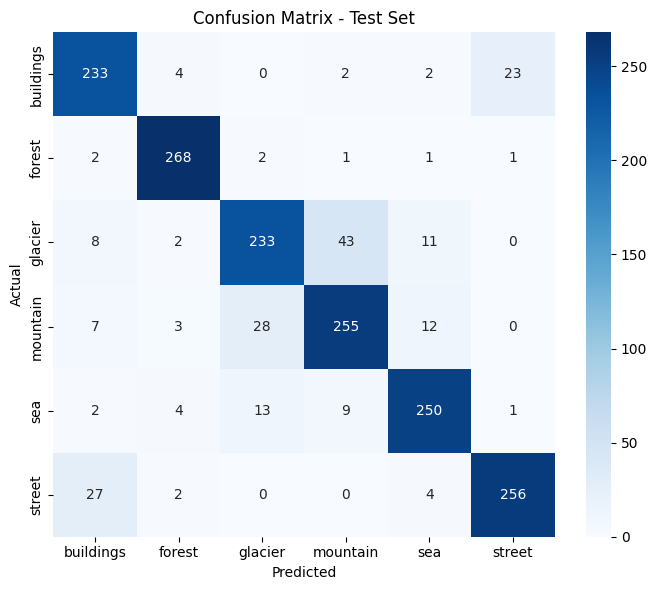

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

label_map = {v: k for k, v in test_generator.class_indices.items()}
target_names = [label_map[i] for i in range(len(label_map))]

print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()


## 9. Inferensi Gambar Baru

Uji model dengan gambar baru (upload manual atau ambil sampel dari test set) dan tampilkan hasil prediksi beserta gambarnya.

Upload satu atau lebih gambar untuk diuji (opsional, bisa di-skip dengan Cancel):


Saving 24267.jpg to 24267.jpg


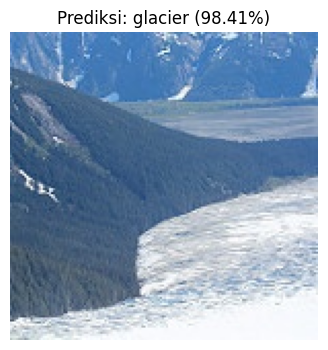

In [17]:
def predict_and_show(img_path, model, class_indices, img_size=(150, 150)):
    label_map = {v: k for k, v in class_indices.items()}
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize(img_size)
    arr = np.array(img_resized) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_label = label_map[pred_idx]
    confidence = preds[pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {pred_label} ({confidence:.2f}%)")
    plt.show()

    return pred_label, confidence

# Opsi A: upload gambar baru secara manual
from google.colab import files as colab_files
print("Upload satu atau lebih gambar untuk diuji (opsional, bisa di-skip dengan Cancel):")
uploaded_new = colab_files.upload()

for fname in uploaded_new:
    predict_and_show(fname, model, train_generator.class_indices)


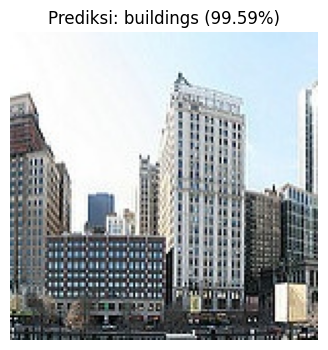

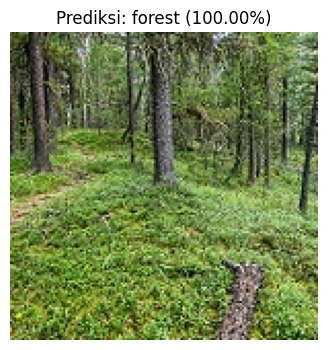

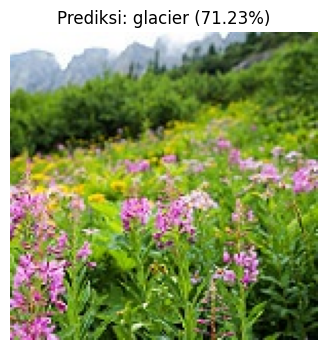

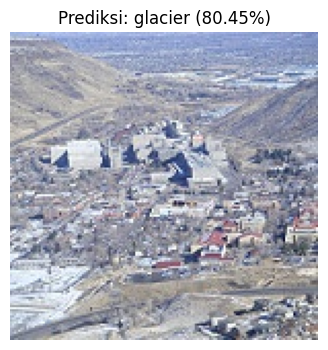

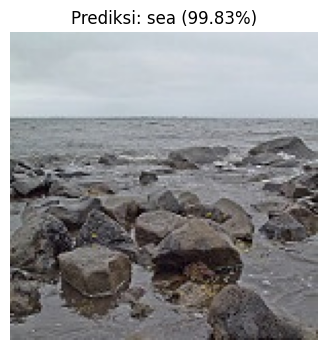

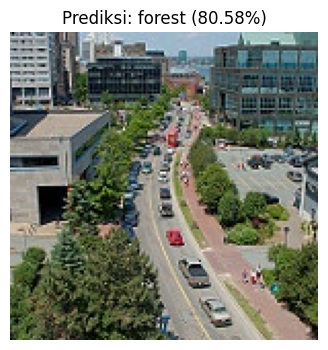

In [18]:
# Opsi B: ambil beberapa sampel acak dari test set sebagai bukti inferensi
import random

sample_paths = []
for cls in class_names:
    cls_dir = os.path.join(TEST_DIR, cls)
    fname = random.choice(os.listdir(cls_dir))
    sample_paths.append(os.path.join(cls_dir, fname))

for p in sample_paths:
    predict_and_show(p, model, train_generator.class_indices)


## 10. Konversi & Export Model

Model diekspor ke tiga format: SavedModel, TF-Lite, dan TFJS.

In [19]:
os.makedirs('/content/submission/saved_model', exist_ok=True)
os.makedirs('/content/submission/tflite', exist_ok=True)
os.makedirs('/content/submission/tfjs_model', exist_ok=True)

# 10a. SavedModel
model.export('/content/submission/saved_model')
print("SavedModel tersimpan.")


Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137804635455952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635456720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635458640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635456144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635457680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635458256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635458448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635460176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137804635460368: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [20]:
# 10b. TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model('/content/submission/saved_model')
tflite_model = converter.convert()

tflite_path = '/content/submission/tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

label_path = '/content/submission/tflite/label.txt'
with open(label_path, 'w') as f:
    for cls in target_names:
        f.write(cls + '\n')

print("TF-Lite model dan label tersimpan.")


TF-Lite model dan label tersimpan.


In [21]:
# 10c. TFJS
!tensorflowjs_converter --input_format=tf_saved_model \
    /content/submission/saved_model \
    /content/submission/tfjs_model

print("TFJS model tersimpan.")
!ls /content/submission/tfjs_model


2026-07-24 14:20:13.755182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784902813.777209   14978 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784902813.784529   14978 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784902813.804833   14978 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784902813.804878   14978 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784902813.804883   14978 computation_placer.cc:177] computation placer alr

## 11. Struktur Folder & Zipping Submission

Menyalin notebook ini, membuat `README.md` dan `requirements.txt`, lalu menyusun semuanya sesuai struktur Dicoding dan mengompresnya menjadi `submission.zip`.

In [22]:
readme_content = f'''# Submission Klasifikasi Gambar - Intel Image Classification

## Deskripsi
Model CNN untuk mengklasifikasikan gambar pemandangan alam ke dalam {num_classes} kelas: {", ".join(class_names)}.

## Dataset
Intel Image Classification (Kaggle) - https://www.kaggle.com/datasets/puneet6060/intel-image-classification

## Hasil
- Test Accuracy: {test_acc:.4f}
- Test Loss: {test_loss:.4f}

## Struktur Model
Sequential CNN: 4 blok Conv2D + MaxPooling2D, Flatten, Dropout, Dense.

## Format Export
- SavedModel: saved_model/
- TensorFlow Lite: tflite/model.tflite + tflite/label.txt
- TensorFlow.js: tfjs_model/
'''

with open('/content/submission/README.md', 'w') as f:
    f.write(readme_content)

print(readme_content)


# Submission Klasifikasi Gambar - Intel Image Classification

## Deskripsi
Model CNN untuk mengklasifikasikan gambar pemandangan alam ke dalam 6 kelas: buildings, forest, glacier, mountain, sea, street.

## Dataset
Intel Image Classification (Kaggle) - https://www.kaggle.com/datasets/puneet6060/intel-image-classification

## Hasil
- Test Accuracy: 0.8748
- Test Loss: 0.3629

## Struktur Model
Sequential CNN: 4 blok Conv2D + MaxPooling2D, Flatten, Dropout, Dense.

## Format Export
- SavedModel: saved_model/
- TensorFlow Lite: tflite/model.tflite + tflite/label.txt
- TensorFlow.js: tfjs_model/



In [23]:
requirements_content = '''tensorflow==2.17.0
tensorflowjs==4.20.0
numpy==1.26.4
pandas==2.2.2
matplotlib==3.9.0
seaborn==0.13.2
scikit-learn==1.5.0
Pillow==10.3.0
split-folders==0.5.1
'''

with open('/content/submission/requirements.txt', 'w') as f:
    f.write(requirements_content)

print(requirements_content)


tensorflow==2.17.0
tensorflowjs==4.20.0
numpy==1.26.4
pandas==2.2.2
matplotlib==3.9.0
seaborn==0.13.2
scikit-learn==1.5.0
Pillow==10.3.0
split-folders==0.5.1



In [24]:
# Salin notebook ini ke folder submission
# Jika dijalankan di Colab, file notebook aktif bisa disalin manual via menu
# File > Download > Download .ipynb, lalu upload ke folder submission, ATAU
# jalankan sel berikut jika notebook sudah tersimpan ke Google Drive / lokal.

import shutil

NOTEBOOK_SOURCE = '/content/notebook.ipynb'  # ganti sesuai lokasi file .ipynb Anda
NOTEBOOK_DEST = '/content/submission/notebook.ipynb'

if os.path.exists(NOTEBOOK_SOURCE):
    shutil.copy2(NOTEBOOK_SOURCE, NOTEBOOK_DEST)
    print("Notebook disalin ke folder submission.")
else:
    print("File notebook.ipynb belum ditemukan di /content. "
          "Download notebook ini (File > Download .ipynb), lalu upload ke /content "
          "dengan nama notebook.ipynb sebelum menjalankan sel ini lagi.")


File notebook.ipynb belum ditemukan di /content. Download notebook ini (File > Download .ipynb), lalu upload ke /content dengan nama notebook.ipynb sebelum menjalankan sel ini lagi.


In [25]:
# Cek struktur folder submission
!find /content/submission -maxdepth 2

# Kompres menjadi submission.zip
shutil.make_archive('/content/submission', 'zip', '/content/submission')
print("\nsubmission.zip berhasil dibuat di /content/submission.zip")


/content/submission
/content/submission/README.md
/content/submission/saved_model
/content/submission/saved_model/fingerprint.pb
/content/submission/saved_model/saved_model.pb
/content/submission/saved_model/assets
/content/submission/saved_model/variables
/content/submission/tflite
/content/submission/tflite/label.txt
/content/submission/tflite/model.tflite
/content/submission/requirements.txt
/content/submission/tfjs_model
/content/submission/tfjs_model/model.json
/content/submission/tfjs_model/group1-shard2of4.bin
/content/submission/tfjs_model/group1-shard4of4.bin
/content/submission/tfjs_model/group1-shard1of4.bin
/content/submission/tfjs_model/group1-shard3of4.bin

submission.zip berhasil dibuat di /content/submission.zip


In [26]:
# (Opsional) unduh submission.zip langsung ke komputer
from google.colab import files as colab_files
colab_files.download('/content/submission.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>